# Занятие 8. Преобразования данных в Pandas и масштабирование

Это последнее занятие курса. Собираем несколько важных приёмов, которые нужны при реальной работе с таблицами.

Сегодня:

1. как выбирать способ преобразования данных;
2. векторные операции;
3. `map`;
4. `apply`;
5. где уместна `lambda`, а где она только усложняет код;
6. изменение части таблицы через `loc` и `iloc`;
7. ручное перекодирование категорий через словарь;
8. обход строк через `iterrows()` / `itertuples()`;
9. масштабирование числовых признаков.

Главная идея:

> **сначала используем самый простой и естественный для Pandas способ; `apply` и `lambda` нужны не для каждой задачи.**


## Что нужно уметь после занятия

После занятия важно уметь:

- выполнять преобразования сразу над столбцом;
- выбирать между векторной операцией, `.str`, `map` и `apply`;
- использовать словарь для перекодирования;
- писать короткие `lambda`-функции;
- применять функцию к строкам `DataFrame`;
- изменять выбранные строки и столбцы через `loc`;
- понимать разницу между `loc` и `iloc`;
- масштабировать числовые признаки.


# 1. Загружаем знакомый реальный датасет

Используем **Palmer Penguins**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:


df = pd.read_csv("/content/drive/MyDrive/itmo_ai_minor_2026(autumn)/Lesson8/lesson_08_penguins.csv")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
df.shape, df.dtypes


((344, 8),
 species               object
 island                object
 bill_length_mm       float64
 bill_depth_mm        float64
 flipper_length_mm    float64
 body_mass_g          float64
 sex                   object
 year                   int64
 dtype: object)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


# 2. Как вообще преобразовывать столбцы?

В Pandas одна и та же задача иногда решается несколькими способами.

Полезный порядок выбора:

```text
простая операция с числами?
        ↓
векторная операция

операция со строками?
        ↓
.str

нужно заменить значения по словарю?
        ↓
.map(dict)

нужна небольшая своя функция для одного значения?
        ↓
.map(function) / .apply(function)

логика зависит от нескольких столбцов одной строки?
        ↓
DataFrame.apply(..., axis=1)
```

`apply` — не «главный способ преобразования Pandas». Часто без него код проще и быстрее.


# 3. Векторные операции — первый выбор для чисел

Переведём массу из граммов в килограммы.


In [8]:
%time
df["body_mass_kg"] = df["body_mass_g"] / 1000

df[["body_mass_g", "body_mass_kg"]].head()


CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.72 µs


,body_mass_g,body_mass_kg
0,3750.0,3.75
1,3800.0,3.80
2,3250.0,3.25
3,NaN,NaN
4,3450.0,3.45


Здесь **не нужен** ни цикл, ни `apply`, ни `lambda`.

Pandas умеет применить арифметическую операцию ко всему столбцу сразу.


### Мини-практика 1

Создайте столбец `bill_length_cm`, переведя длину клюва из миллиметров в сантиметры.


In [ ]:
# TODO

# 4. Для строк сначала вспоминаем `.str`

Например, сделать название вида строчными буквами:


In [11]:
df["species"].str.lower()

,species
0,adelie
1,adelie
2,adelie
3,adelie
4,adelie
...,...
339,chinstrap
340,chinstrap
341,chinstrap
342,chinstrap


In [12]:
df["species_lower"] = df["species"].str.lower()

df[["species", "species_lower"]].head()


,species,species_lower
0,Adelie,adelie
1,Adelie,adelie
2,Adelie,adelie
3,Adelie,adelie
4,Adelie,adelie


Так тоже можно написать через `lambda`:

```python
df["species"].apply(lambda x: x.lower())
```

Но здесь это хуже: у Pandas уже есть специальный строковый интерфейс `.str`.

Правило:

> если есть понятный встроенный векторный метод Pandas — обычно используем его, а не `lambda`.


## Где граница `.str`?

`.str` покрывает очень много стандартных операций со строками:

```python
.str.lower()
.str.upper()
.str.strip()
.str.len()
.str.contains(...)
.str.startswith(...)
.str.replace(...)
.str.split(...)
.str.extract(...)
```

Поэтому если задача — обычное строковое преобразование или регулярное выражение, сначала ищем решение через `.str`.

Но `.str` — не интерфейс для произвольной Python-логики. Если для преобразования нет понятного строкового метода и оно описывается своей функцией, можно переходить к `map` / `apply`.


### Пример 1. `lambda` возможна, но `.str` лучше

Нужно получить код:

```text
Adelie → A-6
Gentoo → G-6
Chinstrap → C-9
```

Через `lambda`:


In [15]:
df["species_code_lambda"] = df["species"].apply(
    lambda s: f"{s[0].upper()}-{len(s)}"
)

df[["species", "species_code_lambda"]].drop_duplicates()


,species,species_code_lambda
0,Adelie,A-6
152,Gentoo,G-6
276,Chinstrap,C-9


Но здесь всё состоит из стандартных строковых операций, поэтому можно остаться в `.str`:


In [16]:
df["species_code_str"] = (
    df["species"].str[0].str.upper()
    + "-"
    + df["species"].str.len().astype(str)
)

df[["species", "species_code_str"]].drop_duplicates()


,species,species_code_str
0,Adelie,A-6
152,Gentoo,G-6
276,Chinstrap,C-9


Оба варианта работают, но второй лучше показывает принцип:

> если задача естественно выражается встроенными операциями Pandas — предпочитаем их.

`lambda` здесь технически возможна, но не нужна.


### Пример 2. Своя логика — функция уже оправдана

Представим строки с измерениями в разных единицах:

```text
"4.2 kg"
"3800 g"
"5 kg"
```

Нужно привести всё к граммам. Одной готовой `.str`-операции для такой бизнес-логики нет. Можно собрать несколько масок и строковых операций, но небольшая функция читается проще:


In [19]:
value, unit = "4.2 kg".split()
value

'4.2'

In [20]:
unit

'kg'

In [21]:
weights = pd.Series(["4.2 kg", "3800 g", "5 kg"])

def to_grams(text):
    value, unit = text.split()
    value = float(value)

    if unit == "kg":
        return value * 1000
    return value

weights.apply(to_grams)


,0
0,4200.0
1,3800.0
2,5000.0


Здесь вопрос не в том, «можно ли теоретически обойтись без `apply`», а в том:

> есть ли простой и читаемый векторный способ?

Если да — используем его. Если нет и логика действительно индивидуальна для каждого значения — `map` / `apply` уместны.


# 5. `map`: преобразование каждого значения Series

Один из самых удобных случаев для `map` — **словарь соответствий**.

Например, хотим русские подписи видов:


In [22]:
species_ru = {
    "Adelie": "Адели",
    "Chinstrap": "Антарктический",
    "Gentoo": "Папуанский",
}

df["species_ru"] = df["species"].map(species_ru)

df[["species", "species_ru"]].drop_duplicates()


,species,species_ru
0,Adelie,Адели
152,Gentoo,Папуанский
276,Chinstrap,Антарктический


`map` берёт каждое значение Series и ищет его в словаре.

Важно: если ключа в словаре нет, результатом будет `NaN`.


## `map` с функцией

Вместо словаря можно передать функцию.


In [25]:
def mass_label(x):
    if pd.isna(x):
        return np.nan
    if x >= 4500:
        return "large"
    return "small"

df["mass_label"] = df["body_mass_g"].map(mass_label)

df[["body_mass_g", "mass_label"]].head(10)


,body_mass_g,mass_label
0,3750.0,small
1,3800.0,small
2,3250.0,small
3,NaN,NaN
4,3450.0,small
5,3650.0,small
6,3625.0,small
7,4675.0,large
8,3475.0,small
9,4250.0,small


## Почему здесь `map`, а не `apply`?

Если задача — обычное соответствие:

```text
Adelie → Адели
Gentoo → Папуанский
```

словарь + `map` прямо описывают смысл операции.

Технически можно написать:


In [ ]:
df["species_ru_apply"] = df["species"].apply(
    lambda x: species_ru.get(x)
)


Но это хуже читается: мы вручную реализовали то, что `map` уже умеет.

> **таблица соответствий → `map(dict)`**


# 6. Где появляется `lambda`?

`lambda` — короткая функция без имени.

Обычная функция:

```python
def square(x):
    return x ** 2
```

То же самое в короткой форме:

```python
lambda x: x ** 2
```

Она удобна, когда логика действительно маленькая и используется один раз.


In [26]:
df["mass_label_lambda"] = df["body_mass_g"].map(
    lambda x: np.nan if pd.isna(x) else ("large" if x >= 4500 else "small")
    )

df[["body_mass_g", "mass_label_lambda"]].head()


,body_mass_g,mass_label_lambda
0,3750.0,small
1,3800.0,small
2,3250.0,small
3,NaN,NaN
4,3450.0,small


Но если условие становится длинным, именованная функция читается лучше.

Плохо:

```python
lambda x: ...очень длинная логика...
```

Лучше:

```python
def classify_mass(x):
    ...
```


# 7. `apply` для Series

`Series.apply()` тоже применяет функцию к каждому значению.

Например:


In [29]:
df["bill_length_rounded"] = df["bill_length_mm"].apply(
    lambda x: int(x) if pd.notna(x) else np.nan
)

df[["bill_length_mm", "bill_length_rounded"]].head()


,bill_length_mm,bill_length_rounded
0,39.1,39.0
1,39.5,39.0
2,40.3,40.0
3,NaN,NaN
4,36.7,36.0


Для простого округления это учебный пример: в реальном коде проще:

```python
df["bill_length_mm"].round(1)
```

Это ещё раз показывает правило: **не тянем `apply` туда, где Pandas уже умеет делать операцию напрямую.**


# 8. `DataFrame.apply(..., axis=1)`: логика по нескольким столбцам

Вот здесь `apply` действительно становится полезным.

Создадим описание наблюдения, используя сразу `species`, `island` и `sex`.


In [30]:
df.iloc[0]

,0
species,Adelie
island,Torgersen
bill_length_mm,39.1
bill_depth_mm,18.7
flipper_length_mm,181.0
body_mass_g,3750.0
sex,male
year,2007
body_mass_kg,3.75
species_lower,adelie


In [32]:
def penguin_description(row):
    sex = row["sex"] if pd.notna(row["sex"]) else "unknown"
    return f'{row["species"]}, {row["island"]}, {sex}'

df["description"] = df.apply(
    penguin_description,
    axis=1,
)

df[["species", "island", "sex", "description"]].head()


,species,island,sex,description
0,Adelie,Torgersen,male,"Adelie, Torgersen, male"
1,Adelie,Torgersen,female,"Adelie, Torgersen, female"
2,Adelie,Torgersen,female,"Adelie, Torgersen, female"
3,Adelie,Torgersen,NaN,"Adelie, Torgersen, unknown"
4,Adelie,Torgersen,female,"Adelie, Torgersen, female"


`axis=1` означает: функция получает **одну строку**.

Для больших таблиц `apply(axis=1)` может быть медленным, поэтому используем его тогда, когда логика действительно зависит от нескольких столбцов и нет более простого решения.


In [33]:
from tqdm.notebook import tqdm
import time



In [34]:
for i in tqdm(range(100)):
    time.sleep(0.05)

  0%|          | 0/100 [00:00<?, ?it/s]

### Мини-практика 2

Создайте столбец `body_summary`.

Правило:

- если масса ≥ 4500 г и длина ласта ≥ 210 мм → `"large"`;
- иначе → `"regular"`;
- если одного из нужных значений нет → `NaN`.

Сделайте это через отдельную функцию и `df.apply(..., axis=1)`.


In [ ]:
# TODO

## Но даже `apply(axis=1)` — не первый выбор

Если условие по нескольким столбцам простое, часто лучше использовать маску:


In [36]:
df["large_fast"] = False

mask = (
    (df["body_mass_g"] >= 4500)
    & (df["flipper_length_mm"] >= 210)
)

df.loc[mask, "large_fast"] = True

df[["body_mass_g", "flipper_length_mm", "large_fast"]].sample(15)


,body_mass_g,flipper_length_mm,large_fast
99,4100.0,192.0,False
96,3700.0,190.0,False
258,4700.0,210.0,True
118,3350.0,189.0,False
266,4375.0,217.0,False
42,3100.0,186.0,False
206,4900.0,217.0,True
65,3950.0,192.0,False
217,5700.0,230.0,True
39,4650.0,184.0,False


Для такого условия `loc` + маска проще и обычно быстрее.

`apply(axis=1)` полезен, когда:

- логика ветвится;
- используются несколько столбцов;
- результат трудно выразить одной-двумя масками;
- небольшая пользовательская функция заметно читабельнее.


## Когда нужен цикл по строкам: `iterrows()`

До этого мы старались **не ходить по строкам вручную**:

- арифметика → векторные операции;
- строки → `.str`;
- замены по словарю → `map`;
- простые условия → маски + `loc`;
- сложная логика по нескольким столбцам → `apply(axis=1)`.

Но иногда действительно нужно обработать строки **по одной**.

Для этого у `DataFrame` есть `iterrows()`:


In [42]:
for index, row in df.head(3).iterrows():
    print(index)
    print(row["species"])
    print("*"*50)


0
Adelie
**************************************************
1
Adelie
**************************************************
2
Adelie
**************************************************


In [37]:
for index, row in df.head(3).iterrows():
    print(
        "index =", index,
        "| species =", row["species"],
        "| body_mass_g =", row["body_mass_g"],
    )


index = 0 | species = Adelie | body_mass_g = 3750.0
index = 1 | species = Adelie | body_mass_g = 3800.0
index = 2 | species = Adelie | body_mass_g = 3250.0


`iterrows()` на каждой итерации возвращает:

```text
index
row
```

где `row` — объект `Series`, содержащий значения одной строки.

То есть внутри цикла можно обращаться к столбцам привычным способом:

```python
row["species"]
row["body_mass_g"]
```


### Читать строку можно. А как изменить DataFrame?

Важно:

```python
for index, row in df.iterrows():
    row["body_mass_g"] = ...
```

**не стоит использовать как способ изменения исходного `df`.**

`row` — отдельный объект, и изменение его значения не является надёжным способом изменить таблицу.

Если во время обхода действительно нужно записать значение обратно, используем индекс и `.at` / `.loc`.


In [43]:
df_iter = df.copy()
df_iter["mass_group_iter"] = None

for index, row in df_iter.iterrows():
    mass = row["body_mass_g"]

    if pd.isna(mass):
        label = None
    elif mass < 3500:
        label = "light"
    elif mass >= 5000:
        label = "heavy"
    else:
        label = "medium"

    df_iter.at[index, "mass_group_iter"] = label

df_iter[["body_mass_g", "mass_group_iter"]].head(15)


,body_mass_g,mass_group_iter
0,3750.0,medium
1,3800.0,medium
2,3250.0,light
3,NaN,None
4,3450.0,light
5,3650.0,medium
6,3625.0,medium
7,4675.0,medium
8,3475.0,light
9,4250.0,medium


`.at[index, "column"]` удобен, когда внутри цикла нужно изменить **одно конкретное значение**.

Можно было использовать и:

```python
df_iter.loc[index, "mass_group_iter"] = label
```

Но для одного элемента `.at` обычно проще.


### Но нужен ли здесь `iterrows()`?

На самом деле — нет.

Эта конкретная задача проще решается через `loc`:


In [44]:
df_fast = df.copy()
df_fast["mass_group"] = "medium"

df_fast.loc[df_fast["body_mass_g"] < 3500, "mass_group"] = "light"
df_fast.loc[df_fast["body_mass_g"] >= 5000, "mass_group"] = "heavy"
df_fast.loc[df_fast["body_mass_g"].isna(), "mass_group"] = None

df_fast[["body_mass_g", "mass_group"]].head(15)


,body_mass_g,mass_group
0,3750.0,medium
1,3800.0,medium
2,3250.0,light
3,NaN,None
4,3450.0,light
5,3650.0,medium
6,3625.0,medium
7,4675.0,medium
8,3475.0,light
9,4250.0,medium


То есть `iterrows()` важно **знать**, но не использовать автоматически.

Для простой обработки столбцов цикл обычно:

- длиннее;
- медленнее;
- сложнее читать;
- легче написать с ошибкой.

`iterrows()` становится оправданным, когда на каждой строке происходит действительно отдельное действие, которое неудобно выразить средствами Pandas.


### Когда `iterrows()` может быть уместен

Например:

- для каждой строки нужно вызвать внешний API;
- для каждой строки нужно прочитать отдельный файл;
- нужно выполнить сложную Python-логику с побочными действиями;
- таблица маленькая, а код пишется для отладки или проверки;
- нужно последовательно собрать новую структуру, и векторизация не даёт выигрыша в читаемости.

Для обычного преобразования признаков сначала ищем способ без цикла.


### `itertuples()` — ещё один способ обхода строк

Если строки нужно **только читать**, часто используют `itertuples()`:


In [48]:
df.body_mass_g

,body_mass_g
0,3750.0
1,3800.0
2,3250.0
3,NaN
4,3450.0
...,...
339,4000.0
340,3400.0
341,3775.0
342,4100.0


In [45]:
for row in df.head(3).itertuples():
    print(
        "index =", row.Index,
        "| species =", row.species,
        "| body_mass_g =", row.body_mass_g,
    )


index = 0 | species = Adelie | body_mass_g = 3750.0
index = 1 | species = Adelie | body_mass_g = 3800.0
index = 2 | species = Adelie | body_mass_g = 3250.0


`itertuples()` обычно быстрее `iterrows()` и возвращает строку как tuple-подобный объект.

Упрощённое правило:

```text
нужно читать строки в цикле
        ↓
itertuples()

нужны index + Series и привычный доступ row["column"]
        ↓
iterrows()

нужно просто преобразовать данные
        ↓
скорее всего цикл вообще не нужен
```


### А если нужно добавить новые строки?

Не стоит на каждой итерации расширять `DataFrame` по одной строке.

Лучше сначала собрать новые строки в список словарей:


In [49]:
new_rows = []

for species in ["Adelie", "Gentoo"]:
    new_rows.append({
        "species": species,
        "island": "demo",
    })

df_new_rows = pd.DataFrame(new_rows)
df_new_rows


,species,island
0,Adelie,demo
1,Gentoo,demo


А затем один раз объединить таблицы через `pd.concat()`:

```python
df_result = pd.concat(
    [df_old, df_new_rows],
    ignore_index=True,
)
```

Такой подход обычно понятнее и эффективнее, чем многократно добавлять строки внутрь цикла.


In [55]:
df_old = df.copy()

In [58]:
df_result = pd.concat(
    [df_old, df_new_rows],
    ignore_index=True,
)

In [59]:
df_result

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg,species_lower,species_code_lambda,species_code_str,species_ru,mass_label,mass_label_lambda,bill_length_rounded,description,large_fast
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007.0,3.750,adelie,A-6,A-6,Адели,small,small,39.0,"Adelie, Torgersen, male",False
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007.0,3.800,adelie,A-6,A-6,Адели,small,small,39.0,"Adelie, Torgersen, female",False
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007.0,3.250,adelie,A-6,A-6,Адели,small,small,40.0,"Adelie, Torgersen, female",False
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007.0,NaN,adelie,A-6,A-6,Адели,NaN,NaN,NaN,"Adelie, Torgersen, unknown",False
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007.0,3.450,adelie,A-6,A-6,Адели,small,small,36.0,"Adelie, Torgersen, female",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009.0,3.775,chinstrap,C-9,C-9,Антарктический,small,small,49.0,"Chinstrap, Dream, male",False
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009.0,4.100,chinstrap,C-9,C-9,Антарктический,small,small,50.0,"Chinstrap, Dream, male",False
343,Chinstrap,Dream,50.2,18.7,198.0,3775.0,female,2009.0,3.775,chinstrap,C-9,C-9,Антарктический,small,small,50.0,"Chinstrap, Dream, female",False
344,Adelie,demo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Мини-практика 3

С помощью `iterrows()` пройдите по первым 10 строкам `df`.

Соберите список строк вида:

```text
Adelie — Biscoe
Gentoo — Biscoe
...
```

Используйте `row["species"]` и `row["island"]`.

После этого ответьте:

**стоит ли ради такой задачи создавать новый столбец через `iterrows()`, или здесь есть более простой способ?**


In [61]:
from tqdm.notebook import tqdm

for index, row in tqdm(
    df.iterrows(),
    total=len(df)
):
    # какая-то обработка строки
    pass
    time.sleep(0.05)

  0%|          | 0/344 [00:00<?, ?it/s]

In [66]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [67]:
df["bill_depth_mm_new"] = df["bill_depth_mm"].progress_apply(
    lambda x: x * 2)

  0%|          | 0/344 [00:00<?, ?it/s]

# 9. Изменяем только часть таблицы через `loc`

`loc` выбирает данные **по именам столбцов и условию по строкам**.

Общий шаблон:

```python
df.loc[условие, "столбец"] = новое_значение
```


In [68]:
df["mass_group"] = "medium"

df.loc[df["body_mass_g"] < 3500, "mass_group"] = "light"
df.loc[df["body_mass_g"] >= 5000, "mass_group"] = "heavy"

df[["body_mass_g", "mass_group"]].head(15)


,body_mass_g,mass_group
0,3750.0,medium
1,3800.0,medium
2,3250.0,light
3,NaN,medium
4,3450.0,light
5,3650.0,medium
6,3625.0,medium
7,4675.0,medium
8,3475.0,light
9,4250.0,medium


Можно менять сразу несколько столбцов:


In [69]:
df_loc_demo = df.copy()

mask = df_loc_demo["species"] == "Gentoo"

df_loc_demo.loc[mask, ["species_ru", "mass_group"]].head()


,species_ru,mass_group
152,Папуанский,medium
153,Папуанский,heavy
154,Папуанский,medium
155,Папуанский,heavy
156,Папуанский,heavy


## Важный шаблон: условное изменение

Например, ограничить слишком большое значение:

```python
df.loc[df["price"] > upper, "price"] = upper
```

Это тот же принцип, который используется при clipping выбросов.


## Почему `loc`, а не `apply`?

Задача:

> изменить значения только у строк, удовлетворяющих условию.

Это прямо задача для `loc`.

Можно было бы пересчитать весь столбец через `apply`, но это заставит Python обработать каждое значение отдельно, хотя Pandas умеет проверить условие сразу для всего столбца.

Запоминаем шаблон:

```python
df.loc[mask, "column"] = value
```


# 10. `iloc`: выбор по позиции

`iloc` работает не с именами, а с **номерами строк и столбцов**.

```python
df.iloc[строки, столбцы]
```


In [ ]:
df.iloc[:3, :4]


Например, получим позицию столбца `year`:


In [70]:
year_position = df.columns.get_loc("year")
year_position


7

In [ ]:
df_iloc_demo = df.copy()

# Для примера меняем year в первых двух строках по позиции.
df_iloc_demo.iloc[:2, year_position] = 9999

df_iloc_demo.head()


Практическое правило:

- `loc` — когда важен **смысл**: условие, имя столбца;
- `iloc` — когда важна **позиция**: первые 5 строк, третий столбец.

Для условных преобразований в анализе данных чаще удобнее `loc`.


## Где `iloc` действительно нужен?

`iloc` нужен, когда важна именно позиция:

```python
df.iloc[:10]       # первые 10 строк
df.iloc[:, :3]     # первые 3 столбца
```

Но если условие смысловое — например, «изменить значения только у Gentoo» — лучше `loc`.

`loc` говорит **что именно мы выбираем**, `iloc` — **где физически это лежит**.


# 11. Чего лучше избегать: chained assignment

Не стоит писать:

```python
df[df["species"] == "Gentoo"]["mass_group"] = "heavy"
```

Такой код может работать не так, как ожидается.

Лучше:

```python
df.loc[df["species"] == "Gentoo", "mass_group"] = "heavy"
```


In [72]:
df_fast[df_fast["species"] == "Gentoo"]["mass_group"] = "heavy"

/tmp/ipykernel_502/371855198.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fast[df_fast["species"] == "Gentoo"]["mass_group"] = "heavy"


In [73]:
df_fast.loc[df_fast["species"] == "Gentoo", "mass_group"] = "heavy"

In [74]:
df_fast

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg,species_lower,species_code_lambda,species_code_str,species_ru,mass_label,mass_label_lambda,bill_length_rounded,description,large_fast,mass_group
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.750,adelie,A-6,A-6,Адели,small,small,39.0,"Adelie, Torgersen, male",False,medium
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.800,adelie,A-6,A-6,Адели,small,small,39.0,"Adelie, Torgersen, female",False,medium
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.250,adelie,A-6,A-6,Адели,small,small,40.0,"Adelie, Torgersen, female",False,light
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN,adelie,A-6,A-6,Адели,NaN,NaN,NaN,"Adelie, Torgersen, unknown",False,None
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.450,adelie,A-6,A-6,Адели,small,small,36.0,"Adelie, Torgersen, female",False,light
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,4.000,chinstrap,C-9,C-9,Антарктический,small,small,55.0,"Chinstrap, Dream, male",False,medium
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,3.400,chinstrap,C-9,C-9,Антарктический,small,small,43.0,"Chinstrap, Dream, female",False,light
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,3.775,chinstrap,C-9,C-9,Антарктический,small,small,49.0,"Chinstrap, Dream, male",False,medium
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,4.100,chinstrap,C-9,C-9,Антарктический,small,small,50.0,"Chinstrap, Dream, male",False,medium


# 12. Ручное перекодирование категорий через словарь

Для **бинарной** категории словарь — простой и понятный вариант.


In [75]:
sex_code = {
    "female": 0,
    "male": 1,
}

df["sex_code"] = df["sex"].map(sex_code)

df[["sex", "sex_code"]].drop_duplicates()


,sex,sex_code
0,male,1.0
1,female,0.0
3,NaN,NaN


Это похоже на ручной encoder: мы сами явно задаём соответствие.

Но для **номинальной категории из нескольких значений** числа могут создать искусственный порядок.

Например, делать так для островов:

```text
Biscoe = 0
Dream = 1
Torgersen = 2
```

не означает, что `Torgersen > Dream > Biscoe`.

Для таких признаков обычно используют One-Hot Encoding.


In [ ]:
island_ohe = pd.get_dummies(
    df["island"],
    prefix="island",
    dtype=int,
)

island_ohe.head()


## А когда числовое кодирование категорий нормально?

Когда категория действительно **порядковая**.

Создадим учебный порядковый признак из реальной массы пингвина:


In [79]:
df["mass_order"] = pd.cut(
    df["body_mass_g"],
    bins=[0, 3500, 4500, float("inf")],
    labels=["light", "medium", "heavy"],
)
df["mass_order"]

,mass_order
0,medium
1,medium
2,light
3,NaN
4,light
...,...
339,medium
340,light
341,medium
342,medium


In [78]:
df["mass_order"] = pd.cut(
    df["body_mass_g"],
    bins=[0, 3500, 4500, float("inf")],
    labels=["light", "medium", "heavy"],
)

mass_order_code = {
    "light": 0,
    "medium": 1,
    "heavy": 2,
}

df["mass_order_code"] = df["mass_order"].map(mass_order_code)

df[["body_mass_g", "mass_order", "mass_order_code"]].head(15)


,body_mass_g,mass_order,mass_order_code
0,3750.0,medium,1
1,3800.0,medium,1
2,3250.0,light,0
3,NaN,NaN,NaN
4,3450.0,light,0
5,3650.0,medium,1
6,3625.0,medium,1
7,4675.0,heavy,2
8,3475.0,light,0
9,4250.0,medium,1


Здесь порядок `light < medium < heavy` действительно существует, поэтому `0 < 1 < 2` отражает смысл признака.


# 13. Быстрая памятка: чем преобразовывать?

| Задача | Обычно используем |
|---|---|
| прибавить / умножить весь числовой столбец | векторную операцию |
| строковые преобразования | `.str` |
| заменить значения по словарю | `.map(dict)` |
| короткая функция для каждого значения | `.map(function)` / `.apply(function)` |
| короткая одноразовая функция | `lambda` |
| логика по нескольким столбцам строки | `df.apply(..., axis=1)` |
| изменить часть строк по условию | `.loc[...] = ...` |
| выбрать / изменить по позиции | `.iloc[...]` |

Главное — не выбирать `apply` автоматически.


# 14. Масштабирование: зачем?

У числовых признаков могут быть очень разные диапазоны:

- `bill_length_mm` — десятки;
- `flipper_length_mm` — сотни;
- `body_mass_g` — тысячи.

Для некоторых методов машинного обучения это важно: признак с большими числами может сильнее влиять на расстояния и оптимизацию просто из-за своей единицы измерения.

Масштабирование меняет **шкалу**, но не должно менять смысл порядка наблюдений.


In [80]:
numeric_cols = [
    "bill_length_mm",
    "flipper_length_mm",
    "body_mass_g",
]

df[numeric_cols].describe().loc[["min", "mean", "std", "max"]]


,bill_length_mm,flipper_length_mm,body_mass_g
min,32.100000,172.000000,2700.000000
mean,43.921930,200.915205,4201.754386
std,5.459584,14.061714,801.954536
max,59.600000,231.000000,6300.000000


# 15. Min-Max вручную: ещё одна векторная операция

Для одного столбца можно увидеть механику масштабирования прямо формулой:

```text
(x - min) / (max - min)
```

Минимум становится `0`, максимум — `1`.


In [81]:
x = df["body_mass_g"]

df["body_mass_minmax_manual"] = (
    (x - x.min()) /
    (x.max() - x.min())
)

df[["body_mass_g", "body_mass_minmax_manual"]].head()


,body_mass_g,body_mass_minmax_manual
0,3750.0,0.291667
1,3800.0,0.305556
2,3250.0,0.152778
3,NaN,NaN
4,3450.0,0.208333


In [82]:
df["body_mass_minmax_manual"].agg(["min", "max"])


,body_mass_minmax_manual
min,0.0
max,1.0


## Почему scaler, если формулу можно написать вручную?

Min-Max удобно один раз посчитать вручную, чтобы понять механику.

Но готовый scaler лучше для реальной подготовки данных, потому что он:

- одинаково обрабатывает несколько признаков;
- хранит вычисленные параметры;
- может затем применить то же преобразование к новым данным;
- естественно встраивается в будущий ML-пайплайн.

То есть:

```text
понять механику → ручная формула
реально масштабировать признаки → специализированный scaler
```


# 16. `MinMaxScaler`

То же самое можно делать готовым инструментом `scikit-learn`.


In [83]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numeric_cols] = minmax.fit_transform(
    df[numeric_cols]
)

df_minmax[numeric_cols].describe().loc[["min", "mean", "max"]]


,bill_length_mm,flipper_length_mm,body_mass_g
min,0.000000,0.000000,0.000000
mean,0.429888,0.490088,0.417154
max,1.000000,1.000000,1.000000


# 17. `StandardScaler`

`StandardScaler` приводит каждый признак к шкале, где:

- среднее примерно `0`;
- стандартное отклонение примерно `1`.


In [84]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

df_standard = df.copy()
df_standard[numeric_cols] = standard.fit_transform(
    df[numeric_cols]
)

df_standard[numeric_cols].describe().loc[["mean", "std", "min", "max"]]


,bill_length_mm,flipper_length_mm,body_mass_g
mean,1.662088e-16,-8.725963e-16,4.155221e-17
std,1.001465e+00,1.001465e+00,1.001465e+00
min,-2.168526e+00,-2.059320e+00,-1.875362e+00
max,2.875868e+00,2.142618e+00,2.620248e+00


## Визуально: форма связи сохраняется

До масштабирования:


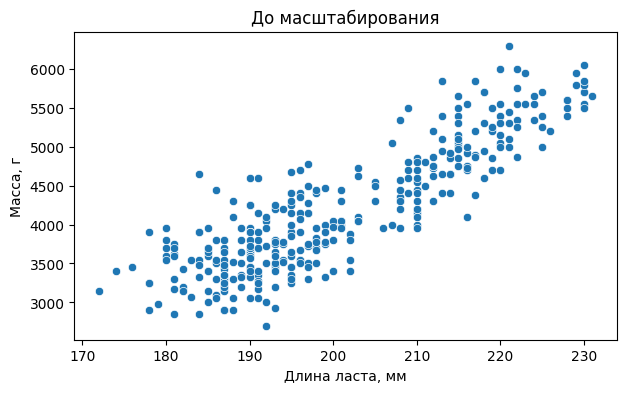

In [85]:
plt.figure(figsize=(7, 4))

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
)

plt.title("До масштабирования")
plt.xlabel("Длина ласта, мм")
plt.ylabel("Масса, г")
plt.show()


После `StandardScaler`:


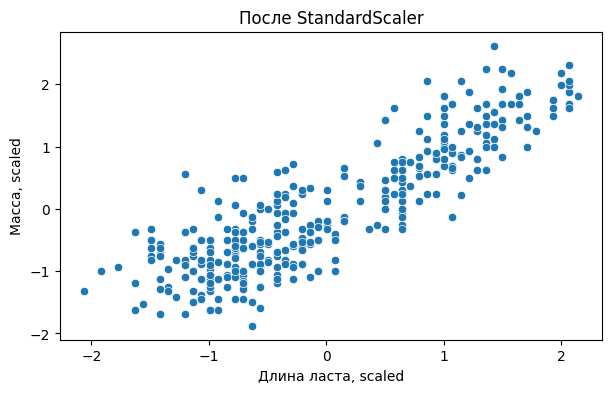

In [86]:
plt.figure(figsize=(7, 4))

sns.scatterplot(
    data=df_standard,
    x="flipper_length_mm",
    y="body_mass_g",
)

plt.title("После StandardScaler")
plt.xlabel("Длина ласта, scaled")
plt.ylabel("Масса, scaled")
plt.show()


Точки не «перемешались»: изменилась шкала осей.

Масштабирование особенно важно для методов, которые используют расстояния или чувствительны к масштабу признаков. Подробно это будет разбираться уже в курсе машинного обучения.


# 18. Что выбрать?

| Способ | Результат | Когда полезен |
|---|---|---|
| `MinMaxScaler` | обычно диапазон 0–1 | когда нужен ограниченный диапазон |
| `StandardScaler` | среднее ≈ 0, std ≈ 1 | частый базовый вариант |
| `RobustScaler` | масштабирование через медиану и IQR | если сильные выбросы мешают обычному scaling |

На этом курсе достаточно понимать идею и уметь применить `MinMaxScaler` и `StandardScaler`.


# Перед практикой: какой инструмент выбрать?

| Задача | Первый выбор | Когда переходить дальше |
|---|---|---|
| арифметика над числовым столбцом | векторная операция | почти никогда не нужен `apply` |
| стандартная работа со строками | `.str` | своей логики нет в `.str` |
| заменить значения по словарю | `.map(dict)` | если это уже не простое соответствие |
| своя функция для каждого значения | `.map(func)` / `.apply(func)` | когда нет простого встроенного метода |
| логика по нескольким столбцам | маски / `loc` | сложная логика → `apply(axis=1)` |
| изменить часть строк | `.loc` | `iloc` — только если важна позиция |
| выбрать по позиции | `.iloc` | если есть смысловое условие → `loc` |
| пройти по строкам для отдельного действия | `itertuples()` / `iterrows()` | только если задачу неудобно выразить векторно |
| масштабировать несколько признаков | scaler | ручная формула — для понимания |

Главный вопрос:

> **какой самый простой метод точно выражает задачу?**


# 19. Мини-практика: собрать всё вместе

На `df`:

1. Создайте `flipper_length_cm` векторной операцией.
2. Через словарь и `map` перекодируйте:
   - `Biscoe → B`;
   - `Dream → D`;
   - `Torgersen → T`.
3. Через `loc` создайте столбец `bill_group`:
   - `< 40` → `"short"`;
   - `40–50` → `"medium"`;
   - `> 50` → `"long"`.
4. Через `apply(axis=1)` создайте короткое текстовое описание из `species` и `island`.
5. Масштабируйте `bill_length_mm`, `flipper_length_mm`, `body_mass_g` через `StandardScaler`.
6. Сравните `describe()` до и после масштабирования.


In [ ]:
# TODO

# 20. Главное с последнего занятия

```text
векторные операции / .str
          ↓
        map
          ↓
 apply, если нужна своя логика
          ↓
 loc / iloc для выборочного изменения
          ↓
 iterrows / itertuples — если без цикла уже неудобно
          ↓
 кодирование категорий
          ↓
 масштабирование числовых признаков
```

И главный практический принцип:

> **чем проще и понятнее преобразование, тем лучше. Не используем `lambda` и `apply` только потому, что можем.**


## Небольшая ремарка про train/test

На этом курсе мы **не разбираем полноценный ML-пайплайн и train/test split** — это логичнее делать вместе с машинным обучением.

Достаточно запомнить на будущее одну мысль:

> когда preprocessing «обучается» на данных (`fit`), в ML-пайплайне его параметры получают только по обучающей части данных.

К этой идее вы вернётесь на следующем курсе.
